# Sprint 7 · Clase teórica comprimida v2 · Preparación, automatización, outliers, segmentación y GitHub

**Duración:** 80 minutos  
**Modalidad:** Teórica con demostraciones cortas  
**Nivel:** Introductorio  

Esta versión comprime los temas de las clases originales en una sola sesión teórica. El foco es explicar los conceptos con código simple y con un dataset más rico, pero sin volver la clase demasiado avanzada.


## Fecha

Completa la información de la sesión:

- **Fecha:** 09/06/2026
- **Instructor/a:** Israel Limon
- **Duración:** 120 minutos


## Objetivos de la sesión teórica

Al finalizar la sesión, la persona estudiante podrá:

1. Reconocer las etapas básicas de un análisis exploratorio de datos.
2. Crear y entender un dataset sintético de ventas multicanal.
3. Identificar valores nulos y aplicar imputaciones simples.
4. Usar **iterables**, ciclos `for`, ciclos `while` y mini-funciones para automatizar tareas repetitivas.
5. Crear gráficos básicos con `.plot()`.
6. Detectar valores atípicos usando la regla IQR.
7. Crear segmentos simples con funciones y `.apply()`.
8. Entender cómo organizar un análisis para publicarlo en GitHub.


## Ejercicio 1 · Crear un dataset sintético

En lugar de usar una tabla pequeña, construiremos un dataset con más variedad:

- País y ciudad.
- Canal de venta.
- Categoría de producto.
- Método de pago.
- Tipo de cliente.
- Ingreso, costo y margen.
- Edad, satisfacción y días de entrega.
- Devoluciones.
- Algunos valores nulos y outliers intencionales.

El objetivo no es memorizar todo el código, sino entender que podemos simular un caso de negocio realista para practicar.


In [1]:
# ============================================================
# Dataset sintético: ventas multicanal
# ============================================================
# Este dataset se crea dentro del notebook para no depender de archivos externos.
# Cada fila representa una venta realizada por un cliente.

import pandas as pd
import random
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Fijamos una semilla para que todos obtengan los mismos datos.
random.seed(7)

paises = ['Colombia', 'México', 'Perú', 'Chile']
ciudades_por_pais = {
    'Colombia': ['Cali', 'Bogotá', 'Medellín', 'Barranquilla'],
    'México': ['CDMX', 'Guadalajara', 'Monterrey', 'Puebla'],
    'Perú': ['Lima', 'Arequipa', 'Cusco', 'Trujillo'],
    'Chile': ['Santiago', 'Valparaíso', 'Concepción', 'La Serena']
}
canales = ['Web', 'App', 'Tienda física', 'WhatsApp']
categorias = ['Tecnología', 'Hogar', 'Ropa', 'Belleza', 'Deportes']
metodos_pago = ['Tarjeta', 'Transferencia', 'Efectivo', 'Billetera digital']
tipos_cliente = ['Nuevo', 'Recurrente']

ventas = []

for venta_id in range(1, 121):
    pais = random.choice(paises)
    ciudad = random.choice(ciudades_por_pais[pais])
    categoria = random.choice(categorias)
    canal = random.choice(canales)
    metodo_pago = random.choice(metodos_pago)
    tipo_cliente = random.choice(tipos_cliente)

    unidades = random.randint(1, 5)
    precio_unitario = random.choice([25000, 40000, 55000, 80000, 120000, 180000, 250000])
    descuento_pct = random.choice([0, 0.05, 0.10, 0.15, 0.20])

    ingreso = unidades * precio_unitario * (1 - descuento_pct)
    costo_total = ingreso * random.choice([0.45, 0.55, 0.65, 0.75])
    margen = ingreso - costo_total

    satisfaccion = random.choice([1, 2, 3, 4, 5, None])
    edad_cliente = random.choice([19, 22, 25, 28, 31, 35, 39, 42, 47, 52, 58, None])
    dias_entrega = random.choice([1, 2, 3, 4, 5, 6, 7, 10, None])
    devolucion = random.choice(['Sí', 'No', 'No', 'No', 'No'])

    ventas.append({
        'venta_id': venta_id,
        'fecha': pd.Timestamp('2026-01-01') + pd.Timedelta(days=random.randint(0, 89)),
        'pais': pais,
        'ciudad': ciudad,
        'canal': canal,
        'categoria': categoria,
        'metodo_pago': metodo_pago,
        'tipo_cliente': tipo_cliente,
        'unidades': unidades,
        'precio_unitario': precio_unitario,
        'descuento_pct': descuento_pct,
        'ingreso': ingreso,
        'costo_total': costo_total,
        'margen': margen,
        'edad_cliente': edad_cliente,
        'satisfaccion': satisfaccion,
        'dias_entrega': dias_entrega,
        'devolucion': devolucion
    })

df = pd.DataFrame(ventas)

# Agregamos algunos casos extremos de forma intencional para practicar outliers.
df.loc[4, 'ingreso'] = 2_800_000
df.loc[4, 'margen'] = 1_250_000
df.loc[18, 'dias_entrega'] = 35
df.loc[50, 'edad_cliente'] = 82
df.loc[90, 'ingreso'] = 1_900_000
df.loc[90, 'margen'] = 850_000

# Guardamos una copia local por si queremos reutilizar el CSV.
# df.to_csv('ventas_multicanal_sprint7_intro.csv', index=False)

print('Dataset creado correctamente')
print('Filas y columnas:', df.shape)
display(df.head())


Dataset creado correctamente
Filas y columnas: (120, 18)


,venta_id,fecha,pais,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo_total,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,1,2026-01-09,Perú,Arequipa,Web,Belleza,Tarjeta,Nuevo,3,120000,0.00,"360,000.00","198,000.00","162,000.00",22.00,1.00,7.00,No
1,2,2026-01-29,México,CDMX,WhatsApp,Deportes,Tarjeta,Nuevo,2,180000,0.20,"288,000.00","129,600.00","158,400.00",52.00,5.00,7.00,Sí
2,3,2026-01-13,Colombia,Bogotá,WhatsApp,Ropa,Transferencia,Nuevo,5,55000,0.20,"220,000.00","121,000.00","99,000.00",52.00,1.00,4.00,No
3,4,2026-03-31,Colombia,Cali,App,Deportes,Billetera digital,Recurrente,3,80000,0.20,"192,000.00","144,000.00","48,000.00",31.00,3.00,4.00,No
4,5,2026-02-13,México,CDMX,Tienda física,Deportes,Billetera digital,Recurrente,4,55000,0.20,"2,800,000.00","79,200.00","1,250,000.00",47.00,1.00,7.00,No


## Diccionario de datos

| Columna | Significado |
|---|---|
| `venta_id` | Identificador único de la venta |
| `fecha` | Fecha de la venta |
| `pais`, `ciudad` | Ubicación del cliente |
| `canal` | Canal usado para comprar: web, app, tienda física o WhatsApp |
| `categoria` | Categoría del producto |
| `metodo_pago` | Forma de pago |
| `tipo_cliente` | Cliente nuevo o recurrente |
| `unidades` | Cantidad comprada |
| `precio_unitario` | Precio antes del descuento |
| `descuento_pct` | Porcentaje de descuento aplicado |
| `ingreso` | Valor vendido después del descuento |
| `costo_total` | Costo estimado de la venta |
| `margen` | Diferencia entre ingreso y costo |
| `edad_cliente` | Edad del cliente |
| `satisfaccion` | Calificación de 1 a 5 |
| `dias_entrega` | Días que tomó la entrega |
| `devolucion` | Indica si hubo devolución |


## Ejercicio 2 · Exploración inicial del dataset

Antes de limpiar o graficar, siempre conviene responder preguntas básicas:

- ¿Cuántas filas y columnas tiene la tabla?
- ¿Qué columnas existen?
- ¿Qué tipos de datos tiene cada columna?
- ¿Hay valores nulos?
- ¿Qué variables numéricas podrían analizarse?


In [2]:
# Tamaño del dataset
print('Filas y columnas:', df.shape)

Filas y columnas: (120, 18)


In [3]:
# Primeras filas
display(df.head())

,venta_id,fecha,pais,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo_total,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,1,2026-01-09,Perú,Arequipa,Web,Belleza,Tarjeta,Nuevo,3,120000,0.00,"360,000.00","198,000.00","162,000.00",22.00,1.00,7.00,No
1,2,2026-01-29,México,CDMX,WhatsApp,Deportes,Tarjeta,Nuevo,2,180000,0.20,"288,000.00","129,600.00","158,400.00",52.00,5.00,7.00,Sí
2,3,2026-01-13,Colombia,Bogotá,WhatsApp,Ropa,Transferencia,Nuevo,5,55000,0.20,"220,000.00","121,000.00","99,000.00",52.00,1.00,4.00,No
3,4,2026-03-31,Colombia,Cali,App,Deportes,Billetera digital,Recurrente,3,80000,0.20,"192,000.00","144,000.00","48,000.00",31.00,3.00,4.00,No
4,5,2026-02-13,México,CDMX,Tienda física,Deportes,Billetera digital,Recurrente,4,55000,0.20,"2,800,000.00","79,200.00","1,250,000.00",47.00,1.00,7.00,No


In [4]:
# Nombres de columnas
print('Columnas disponibles:')
print(df.columns.tolist())

Columnas disponibles:
['venta_id', 'fecha', 'pais', 'ciudad', 'canal', 'categoria', 'metodo_pago', 'tipo_cliente', 'unidades', 'precio_unitario', 'descuento_pct', 'ingreso', 'costo_total', 'margen', 'edad_cliente', 'satisfaccion', 'dias_entrega', 'devolucion']


In [5]:
# Información general: tipos de datos y valores no nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   venta_id         120 non-null    int64         
 1   fecha            120 non-null    datetime64[ns]
 2   pais             120 non-null    object        
 3   ciudad           120 non-null    object        
 4   canal            120 non-null    object        
 5   categoria        120 non-null    object        
 6   metodo_pago      120 non-null    object        
 7   tipo_cliente     120 non-null    object        
 8   unidades         120 non-null    int64         
 9   precio_unitario  120 non-null    int64         
 10  descuento_pct    120 non-null    float64       
 11  ingreso          120 non-null    float64       
 12  costo_total      120 non-null    float64       
 13  margen           120 non-null    float64       
 14  edad_cliente     111 non-null    float64  

In [6]:
# Cantidad de valores nulos por columna
nulos = df.isna().sum()
print(nulos)


venta_id            0
fecha               0
pais                0
ciudad              0
canal               0
categoria           0
metodo_pago         0
tipo_cliente        0
unidades            0
precio_unitario     0
descuento_pct       0
ingreso             0
costo_total         0
margen              0
edad_cliente        9
satisfaccion       21
dias_entrega       12
devolucion          0
dtype: int64


## Ejercicio 3 · Tratamiento simple de valores nulos (8 min)

Para una clase introductoria, usaremos reglas simples:

- Si la columna es numérica, podemos completar con la **mediana**.
- Si la columna es categórica, podemos completar con la **moda** o con una etiqueta como `Sin dato`.

No siempre esta será la mejor decisión en un proyecto real, pero es una estrategia fácil para iniciar.


In [8]:
# Creamos una copia para no modificar el dataset original
df_limpio = df.copy()

In [9]:
# Completamos valores nulos numéricos con la mediana
df_limpio['edad_cliente'] = df_limpio['edad_cliente'].fillna(df_limpio['edad_cliente'].median())
df_limpio['satisfaccion'] = df_limpio['satisfaccion'].fillna(df_limpio['satisfaccion'].median())
df_limpio['dias_entrega'] = df_limpio['dias_entrega'].fillna(df_limpio['dias_entrega'].median())


In [11]:
df_limpio['pais'].mode()

,pais
0,México


In [10]:
print('Nulos después de la limpieza:')
print(df_limpio.isna().sum())

Nulos después de la limpieza:
venta_id           0
fecha              0
pais               0
ciudad             0
canal              0
categoria          0
metodo_pago        0
tipo_cliente       0
unidades           0
precio_unitario    0
descuento_pct      0
ingreso            0
costo_total        0
margen             0
edad_cliente       0
satisfaccion       0
dias_entrega       0
devolucion         0
dtype: int64


## Ejercicio 4 · Automatización con iterables y ciclo `for`

Un **iterable** es un objeto que podemos recorrer elemento por elemento. Algunos ejemplos comunes son:

- Listas.
- Tuplas.
- Diccionarios.
- Columnas de un DataFrame.

Cuando tenemos que repetir la misma acción para varias columnas, un ciclo `for` evita copiar y pegar código.


In [12]:
# Lista de columnas numéricas que queremos revisar
columnas_numericas = ['unidades', 'precio_unitario', 'ingreso', 'margen', 'edad_cliente', 'satisfaccion', 'dias_entrega']

# El ciclo for repite la misma acción para cada columna de la lista
for columna in columnas_numericas:
    promedio = df_limpio[columna].mean()
    minimo = df_limpio[columna].min()
    maximo = df_limpio[columna].max()

    print('Columna:', columna)
    print('Promedio:', round(promedio, 2))
    print('Mínimo:', minimo)
    print('Máximo:', maximo)
    print('-----------------------')


Columna: unidades
Promedio: 3.13
Mínimo: 1
Máximo: 5
-----------------------
Columna: precio_unitario
Promedio: 101041.67
Mínimo: 25000
Máximo: 250000
-----------------------
Columna: ingreso
Promedio: 315306.25
Mínimo: 20000.0
Máximo: 2800000.0
-----------------------
Columna: margen
Promedio: 126563.65
Mínimo: 5312.5
Máximo: 1250000.0
-----------------------
Columna: edad_cliente
Promedio: 34.52
Mínimo: 19.0
Máximo: 82.0
-----------------------
Columna: satisfaccion
Promedio: 2.95
Mínimo: 1.0
Máximo: 5.0
-----------------------
Columna: dias_entrega
Promedio: 4.56
Mínimo: 1.0
Máximo: 35.0
-----------------------


## Ejercicio 5 · Automatización con ciclo `while`

El ciclo `while` se repite **mientras una condición sea verdadera**.

Para principiantes, es más seguro usarlo con un contador claro. Así evitamos ciclos infinitos.


In [13]:
# Revisaremos columnas una por una usando while
columnas_a_revisar = ['ingreso', 'margen', 'dias_entrega']

posicion = 0

while posicion < len(columnas_a_revisar):
    columna = columnas_a_revisar[posicion]
    print('Estamos revisando:', columna)
    print('Promedio:', round(df_limpio[columna].mean(), 2))
    print()

    # Muy importante: actualizar el contador
    posicion = posicion + 1


Estamos revisando: ingreso
Promedio: 315306.25

Estamos revisando: margen
Promedio: 126563.65

Estamos revisando: dias_entrega
Promedio: 4.56



## Ejercicio 6 · Mini-funciones para no repetir código

Una función permite guardar una lógica con nombre y reutilizarla.

Estructura básica:

```python
def nombre_funcion(parametro):
    instrucciones
    return resultado
```

Usaremos funciones pequeñas y legibles.


In [14]:
def mostrar_resumen_columna(tabla, columna):
    """Muestra un resumen básico de una columna numérica."""
    print('Resumen de:', columna)
    print('Promedio:', round(tabla[columna].mean(), 2))
    print('Mediana:', round(tabla[columna].median(), 2))
    print('Mínimo:', tabla[columna].min())
    print('Máximo:', tabla[columna].max())

mostrar_resumen_columna(df_limpio, 'ingreso')


Resumen de: ingreso
Promedio: 315306.25
Mediana: 185000.0
Mínimo: 20000.0
Máximo: 2800000.0


In [15]:
# Podemos combinar funciones + for para automatizar más
for columna in ['ingreso', 'margen', 'dias_entrega']:
    mostrar_resumen_columna(df_limpio, columna)
    print('-----------------------')


Resumen de: ingreso
Promedio: 315306.25
Mediana: 185000.0
Mínimo: 20000.0
Máximo: 2800000.0
-----------------------
Resumen de: margen
Promedio: 126563.65
Mediana: 73400.0
Mínimo: 5312.5
Máximo: 1250000.0
-----------------------
Resumen de: dias_entrega
Promedio: 4.56
Mediana: 4.0
Mínimo: 1.0
Máximo: 35.0
-----------------------


## Ejercicio 7 · Distribuciones y gráficos con `.plot()`

Una distribución nos ayuda a entender cómo se comportan los valores de una variable.

Para iniciar, usaremos dos gráficos simples:

- Histograma para ver la distribución de una variable numérica.
- Barras para comparar grupos.


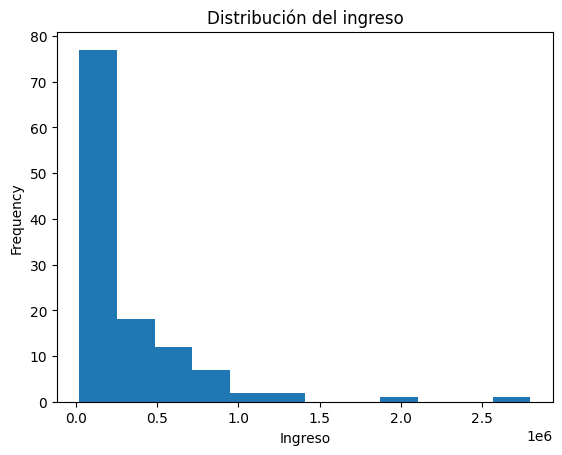

In [16]:
# Histograma del ingreso

df_limpio['ingreso'].plot(kind='hist', bins=12, title='Distribución del ingreso')
plt.xlabel('Ingreso')
plt.show()


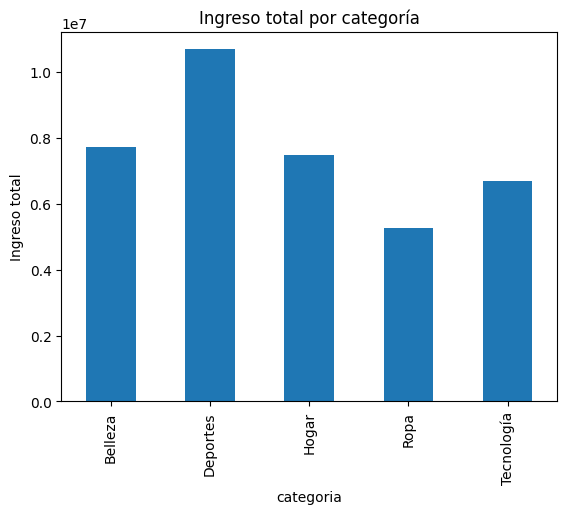

In [17]:
# Ingreso total por categoría

ingreso_por_categoria = df_limpio.groupby('categoria')['ingreso'].sum()

ingreso_por_categoria.plot(kind='bar', title='Ingreso total por categoría')
plt.ylabel('Ingreso total')
plt.show()


## Ejercicio 8 · Detección de outliers con IQR

La regla IQR usa cuartiles para definir límites:

- Q1: percentil 25.
- Q3: percentil 75.
- IQR = Q3 - Q1.
- Límite inferior = Q1 - 1.5 × IQR.
- Límite superior = Q3 + 1.5 × IQR.

Un valor fuera de estos límites puede ser considerado atípico.


In [18]:
def calcular_limites_iqr(tabla, columna):
    """Calcula límites inferior y superior usando IQR."""
    q1 = tabla[columna].quantile(0.25)
    q3 = tabla[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    return limite_inferior, limite_superior

In [19]:
limite_inf, limite_sup = calcular_limites_iqr(df_limpio, 'ingreso')

In [20]:
print('Límite inferior:', limite_inf)
print('Límite superior:', limite_sup)

Límite inferior: -342000.0
Límite superior: 858000.0


In [21]:
# Filtramos ventas con ingreso atípico
outliers_ingreso = df_limpio[df_limpio['ingreso'] > limite_sup]

display(outliers_ingreso[['venta_id', 'pais', 'categoria', 'ingreso', 'margen']])


,venta_id,pais,categoria,ingreso,margen
4,5,México,Deportes,"2,800,000.00","1,250,000.00"
46,47,Perú,Belleza,"900,000.00","495,000.00"
70,71,México,Belleza,"950,000.00","237,500.00"
71,72,Colombia,Deportes,"1,187,500.00","296,875.00"
78,79,Chile,Deportes,"1,187,500.00","296,875.00"
89,90,Chile,Deportes,"1,062,500.00","478,125.00"
90,91,Colombia,Hogar,"1,900,000.00","850,000.00"


## Ejercicio 9 · Segmentación con mini-funciones y `.apply()` (7 min)

Segmentar significa crear grupos o etiquetas para analizar mejor los datos.

Ejemplos:

- Venta pequeña, media o grande.
- Margen bajo, medio o alto.
- Cliente joven, adulto o mayor.


In [22]:
if ingreso >= 500000:
    print('Venta grande')
elif ingreso >= 150000:
    print('Venta media')
elif ingreso >= 100000:
    print("Venta peque-mediana")
elif ingreso >= 50000:
  print("Venta no tan pequeña")
else:
    print('Venta pequeña')

Venta media


In [23]:
def clasificar_venta(ingreso):
    if ingreso >= 500000:
        return 'Venta grande'
    elif ingreso >= 150000:
        return 'Venta media'
    else:
        return 'Venta pequeña'

In [24]:
# apply aplica la función a cada valor de la columna ingreso
df_limpio['segmento_venta'] = df_limpio['ingreso'].apply(clasificar_venta)

display(df_limpio[['venta_id', 'ingreso', 'segmento_venta']].head(10))

,venta_id,ingreso,segmento_venta
0,1,"360,000.00",Venta media
1,2,"288,000.00",Venta media
2,3,"220,000.00",Venta media
3,4,"192,000.00",Venta media
4,5,"2,800,000.00",Venta grande
5,6,"486,000.00",Venta media
6,7,"648,000.00",Venta grande
7,8,"272,000.00",Venta media
8,9,"152,000.00",Venta media
9,10,"432,000.00",Venta media


In [25]:
# Ahora podemos contar ventas por segmento
conteo_segmentos = df_limpio['segmento_venta'].value_counts()
print(conteo_segmentos)

segmento_venta
Venta media      52
Venta pequeña    46
Venta grande     22
Name: count, dtype: int64


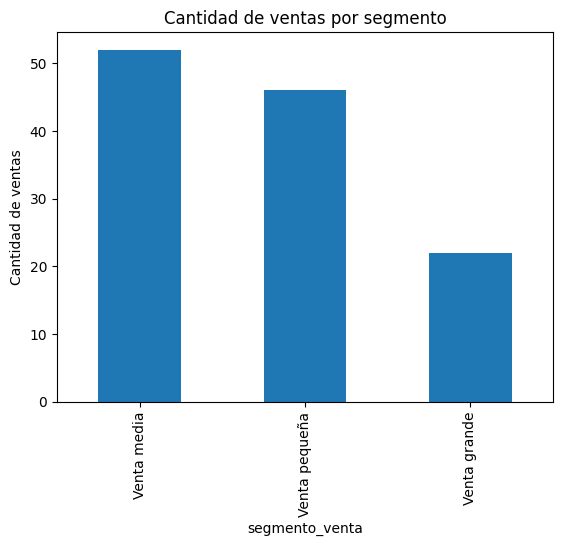

In [26]:
conteo_segmentos.plot(kind='bar', title='Cantidad de ventas por segmento')
plt.ylabel('Cantidad de ventas')
plt.show()


## Ejercicio 10 · Automatizar resúmenes por grupo (5 min)

Con una función y un ciclo `for`, podemos generar varios resúmenes sin repetir código.


In [27]:
def resumen_por_grupo(tabla, grupo):
    resumen = tabla.groupby(grupo).agg({
        'venta_id': 'count',
        'ingreso': 'sum',
        'margen': 'mean',
        'satisfaccion': 'mean'
    })
    return resumen

In [28]:
grupos = ['pais', 'canal', 'categoria']

for grupo in grupos:
    print('Resumen por:', grupo)
    display(resumen_por_grupo(df_limpio, grupo))
    print('-----------------------')


Resumen por: pais


,venta_id,ingreso,margen,satisfaccion
pais,,,,
Chile,29,"8,542,000.00","114,517.24",2.76
Colombia,25,"8,933,250.00","142,244.50",3.04
México,35,"12,127,000.00","140,296.43",2.89
Perú,31,"8,234,500.00","109,682.26",3.13


-----------------------
Resumen por: canal


,venta_id,ingreso,margen,satisfaccion
canal,,,,
App,18,"6,814,500.00","127,823.61",3.22
Tienda física,29,"11,212,250.00","169,050.43",2.97
Web,41,"11,188,500.00","107,765.24",3.10
WhatsApp,32,"8,621,500.00","111,436.72",2.59


-----------------------
Resumen por: categoria


,venta_id,ingreso,margen,satisfaccion
categoria,,,,
Belleza,27,"7,717,000.00","110,987.96",2.96
Deportes,24,"10,682,500.00","162,368.75",3.25
Hogar,26,"7,495,000.00","116,455.77",2.92
Ropa,21,"5,265,250.00","108,410.12",2.86
Tecnología,22,"6,677,000.00","135,893.18",2.73


-----------------------


## Organización mínima para GitHub (5 min)

Para publicar un análisis básico, una estructura sencilla puede ser:

```text
proyecto-ventas-multicanal/
├── data/
│   └── ventas_multicanal_sprint7_intro.csv
├── notebooks/
│   └── analisis_ventas.ipynb
├── images/
│   └── graficos.png
└── README.md
```

El `README.md` debería explicar:

1. Objetivo del proyecto.
2. Dataset usado.
3. Principales pasos del análisis.
4. Hallazgos principales.
5. Cómo ejecutar el notebook.


## Takeaways

- Un dataset realista suele tener variables numéricas, categóricas, fechas, nulos y casos extremos.
- Los ciclos `for` ayudan a repetir una tarea sobre varias columnas o grupos.
- Los ciclos `while` sirven cuando la repetición depende de una condición.
- Las funciones permiten reutilizar lógica sin copiar y pegar código.
- `.plot()` permite crear visualizaciones simples directamente desde Pandas.
- IQR es una regla introductoria para detectar posibles outliers.
- La segmentación convierte valores numéricos en etiquetas más interpretables para negocio.


## Cierre

Pregunta final para discusión:

> Si tuvieras que automatizar una parte del análisis, ¿automatizarías la limpieza de nulos, el cálculo de métricas, los gráficos o la detección de outliers? ¿Por qué?


## Información complementaria

Temas sugeridos para profundizar después:

- Diferencia entre media y mediana.
- Buenas prácticas para tratar outliers.
- Funciones con más de un parámetro.
- Listas, diccionarios y tuplas.
- Automatización de reportes con Pandas.
- Publicación de notebooks en GitHub.
